In [1]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import matplotlib.pyplot as plt
from trace_IO import *


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
lts = LongTraceSimulator(config)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/home/dwong/software/TraceSimulator/TraceSimulator/LongTraceSimulator.py:203: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


In [7]:
trace, signal_mask= lts.generate(
            E=2000,
            x=0,
            y=0,
            z=-1700,
            no_noise=False,
            type_recoil='NR',
            quantize=True,
            phonon_only=False,
            return_signal_mask=True
        )

In [10]:
def plot_traces(traces, fs=3_906_250, offset_step=100, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))
    
    for i in range(num_channels):
        color = 'orange' if i > 19 else 'tab:blue'
        plt.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])  # Hide y-axis ticks

    plt.tight_layout()
    plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_traces(traces, fs=3_906_250, offset_step=100, title="Trace set for v2 Pancake Geometry"):
    # Handle 3D input shaped (1, C, S)
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    fig, ax = plt.subplots(figsize=(18, 12))

    for i in range(num_channels):
        if i > 19:  # vacuum
            ax.plot(
                time_ms, 
                traces[i] + i * offset_step, 
                lw=0.5, 
                color='orange',
                alpha=0.9
            )
        else:  # submerged
            ax.plot(
                time_ms, 
                traces[i] + i * offset_step, 
                lw=0.5, 
                color='tab:blue',
                alpha=0.9
            )

    ax.set_xlabel("Time [ms]", fontsize=16)
    ax.set_ylabel("ADC counts + Offset", fontsize=16)
    ax.set_title(title, fontsize=20, weight="bold")
    ax.set_xlim(0, time_ms[-1])
    ax.set_ylim(-10, offset_step * (num_channels + 1))
    ax.set_yticks([])

    # Outside labels (in black)
    ax.text(
        0.1, 1, "DELight",
        transform=ax.transAxes,
        fontsize=15, weight="bold",
        va="bottom", ha="right", color="black"
    )
    ax.text(
        0.9, 1, "Simulation",
        transform=ax.transAxes,
        fontsize=15, weight="bold",
        va="bottom", ha="left", color="black"
    )

    plt.tight_layout()
    plt.show()


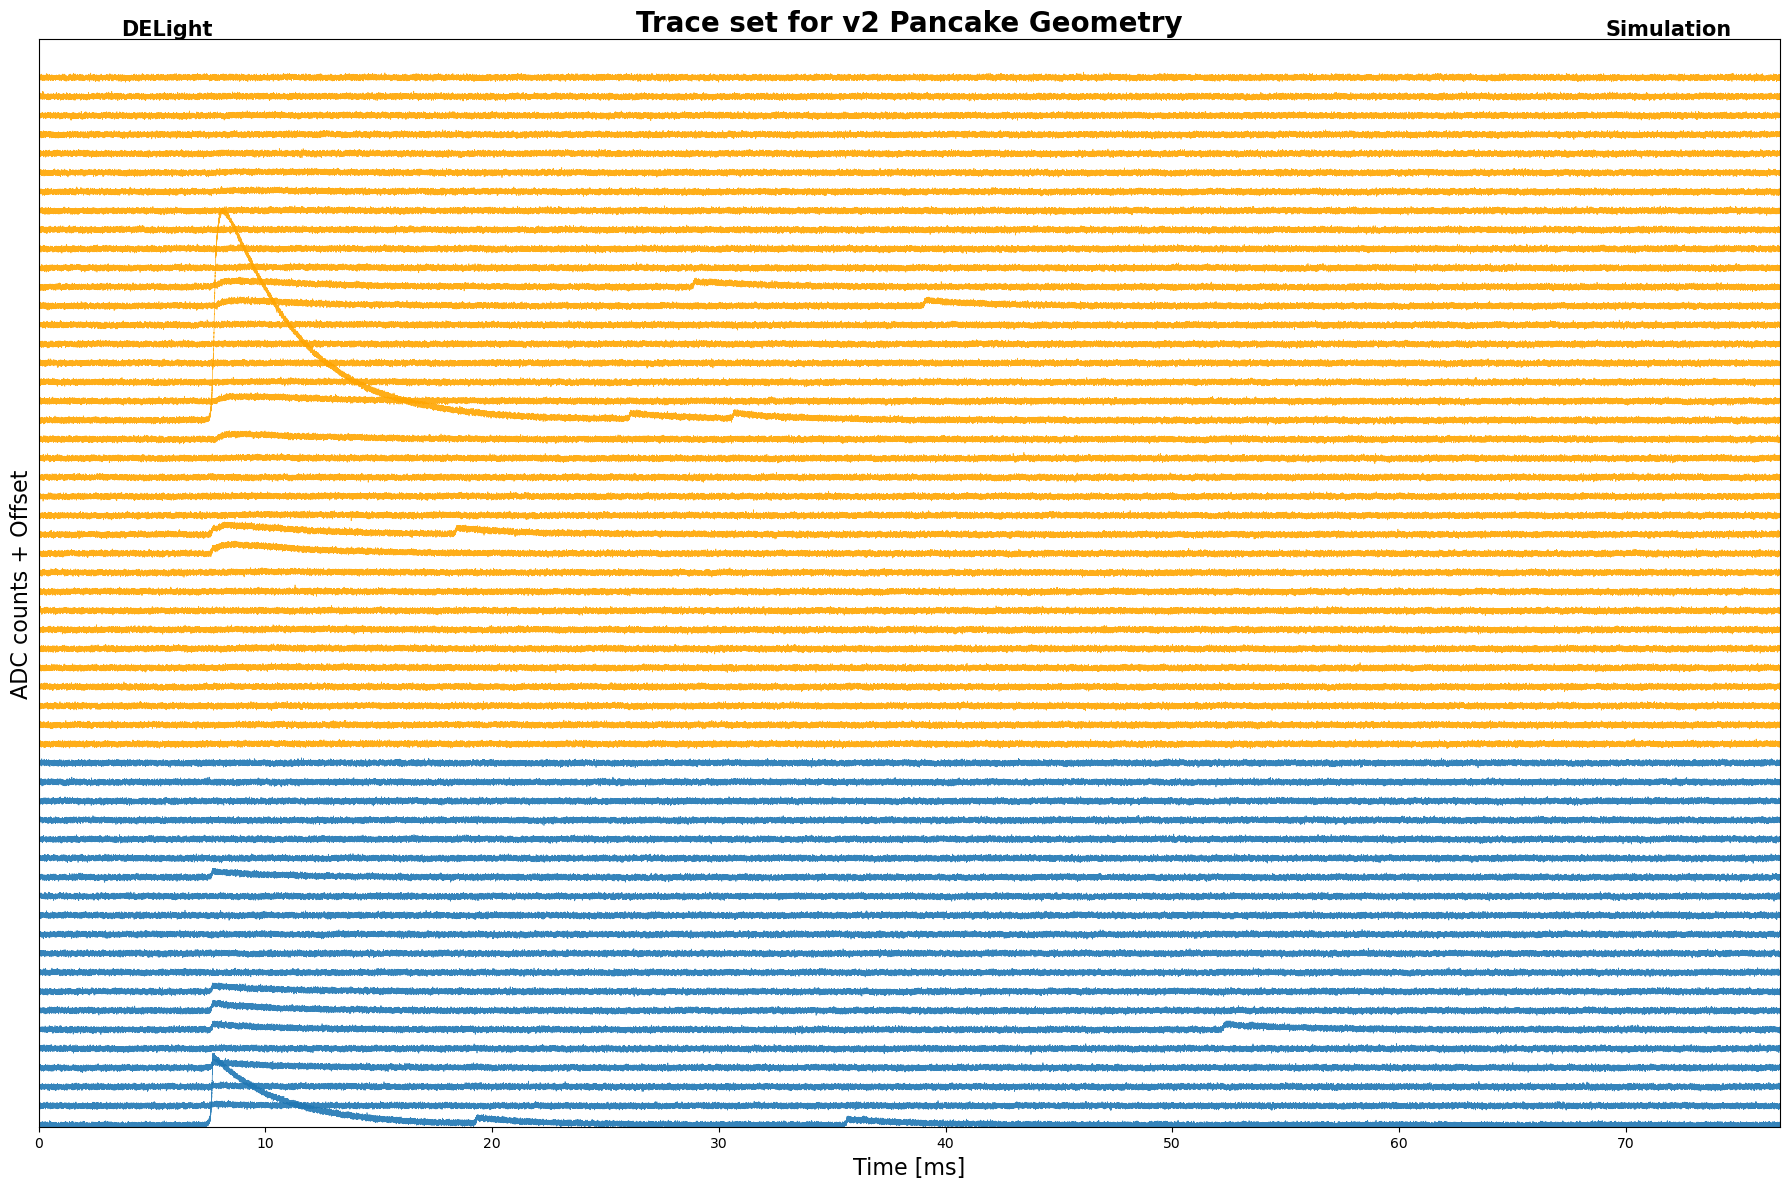

In [27]:
plot_traces(trace)

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_traces_and_geometry(traces, positions, recoil_pos,
                             fs=3_906_250, offset_step=100,
                             sensor_z=-1692,
                             title_traces="Trace set for v2 Pancake Geometry",
                             title_geom="Recoil Event location"):
    """
    traces: ndarray shape (C, S) or (1, C, S)
    positions: ndarray shape (N, 3), sensor positions
    recoil_pos: tuple (x, y, z) of recoil event location
    """

    # ------------------------
    # Prep traces
    # ------------------------
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000

    # ------------------------
    # Prep geometry
    # ------------------------
    hex_radius_sel  = 49.5 / 2.0
    other_scale     = 1.38
    hex_radius_oth  = hex_radius_sel * other_scale
    orientation     = np.pi / 6

    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    mask_sel = (z == sensor_z)    # Vacuum
    mask_oth = ~mask_sel          # Submerged

    selected = positions[mask_sel]
    others   = positions[mask_oth]

    def hexagon_vertices_like_2d(xc, yc, zc, radius):
        rp = RegularPolygon((xc, yc),
                            numVertices=6,
                            radius=radius,
                            orientation=orientation)
        verts2d = rp.get_verts()
        return [(vx, vy, zc) for vx, vy in verts2d]

    # ------------------------
    # Plot side by side
    # ------------------------
    fig = plt.figure(figsize=(28, 12))

    # ---- Left: traces ----
    ax1 = fig.add_subplot(1, 2, 1)
    for i in range(num_channels):
        if i > 19:  # Vacuum
            ax1.plot(time_ms, traces[i] + i * offset_step,
                     lw=0.5, color='orange', alpha=0.9)
        else:       # Submerged
            ax1.plot(time_ms, traces[i] + i * offset_step,
                     lw=0.5, color='tab:blue', alpha=0.9)

    ax1.set_xlabel("Time [ms]", fontsize=16)
    ax1.set_ylabel("ADC counts + Offset", fontsize=16)
    ax1.set_title(title_traces, fontsize=20, weight="bold")
    ax1.set_xlim(0, time_ms[-1])
    ax1.set_ylim(-10, offset_step * (num_channels + 1))
    ax1.set_yticks([])

    # Shoulder labels
    ax1.text(0.05, 1.02, "DELight",
             transform=ax1.transAxes,
             fontsize=18, weight="bold",
             va="bottom", ha="right", color="black")
    ax1.text(0.9, 1.02, "Simulation",
             transform=ax1.transAxes,
             fontsize=18, weight="bold",
             va="bottom", ha="left", color="black")

    # ---- Right: geometry ----
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    # Vacuum (orange)
    for xi, yi, zi in selected:
        verts3d = hexagon_vertices_like_2d(xi, yi, zi, hex_radius_sel)
        ax2.add_collection3d(Poly3DCollection([verts3d],
                                              facecolor="orange",
                                              edgecolor="k",
                                              alpha=0.4,
                                              linewidths=0.8))
    # Submerged (blue)
    for xi, yi, zi in others:
        verts3d = hexagon_vertices_like_2d(xi, yi, zi, hex_radius_oth)
        ax2.add_collection3d(Poly3DCollection([verts3d],
                                              facecolor="royalblue",
                                              edgecolor="k",
                                              alpha=0.5,
                                              linewidths=0.7))

    # Recoil event marker
    rx, ry, rz = recoil_pos
    ax2.scatter(rx, ry, rz, color="red", s=190, marker="*", label="Recoil event")

    # Labels / title
    ax2.set_xlabel("x [mm]", labelpad=10)
    ax2.set_ylabel("y [mm]", labelpad=10)
    ax2.set_zlabel("z [mm]", labelpad=15)
    ax2.set_title(title_geom, fontsize=20, weight="bold")

    # Zoom to selected plane footprint
    zoom_pad = 60.0
    if selected.size > 0:
        sel_xmin, sel_xmax = selected[:,0].min()-zoom_pad, selected[:,0].max()+zoom_pad
        sel_ymin, sel_ymax = selected[:,1].min()-zoom_pad, selected[:,1].max()+zoom_pad
        ax2.set_xlim(sel_xmin, sel_xmax)
        ax2.set_ylim(sel_ymin, sel_ymax)
    else:
        pad = 60.0
        ax2.set_xlim(x.min()-pad, x.max()+pad)
        ax2.set_ylim(y.min()-pad, y.max()+pad)

    z_pad = 50.0
    ax2.set_zlim(z.min()-z_pad, z.max()+z_pad)

    # Camera angle and aspect
    ax2.view_init(elev=15, azim=-50)
    xr, yr, zr = ax2.get_xlim(), ax2.get_ylim(), ax2.get_zlim()
    ax2.set_box_aspect((xr[1]-xr[0], yr[1]-yr[0], zr[1]-zr[0]))

    # Legend for geometry
    legend_handles = [
        Patch(facecolor="orange", edgecolor='k', label='Vacuum channels'),
        Patch(facecolor="royalblue", edgecolor='k', label='Submerged channels'),
        Patch(facecolor="red", edgecolor='k', label='Recoil event'),
    ]
    ax2.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.05, 1.0))

    plt.tight_layout()
    plt.show()


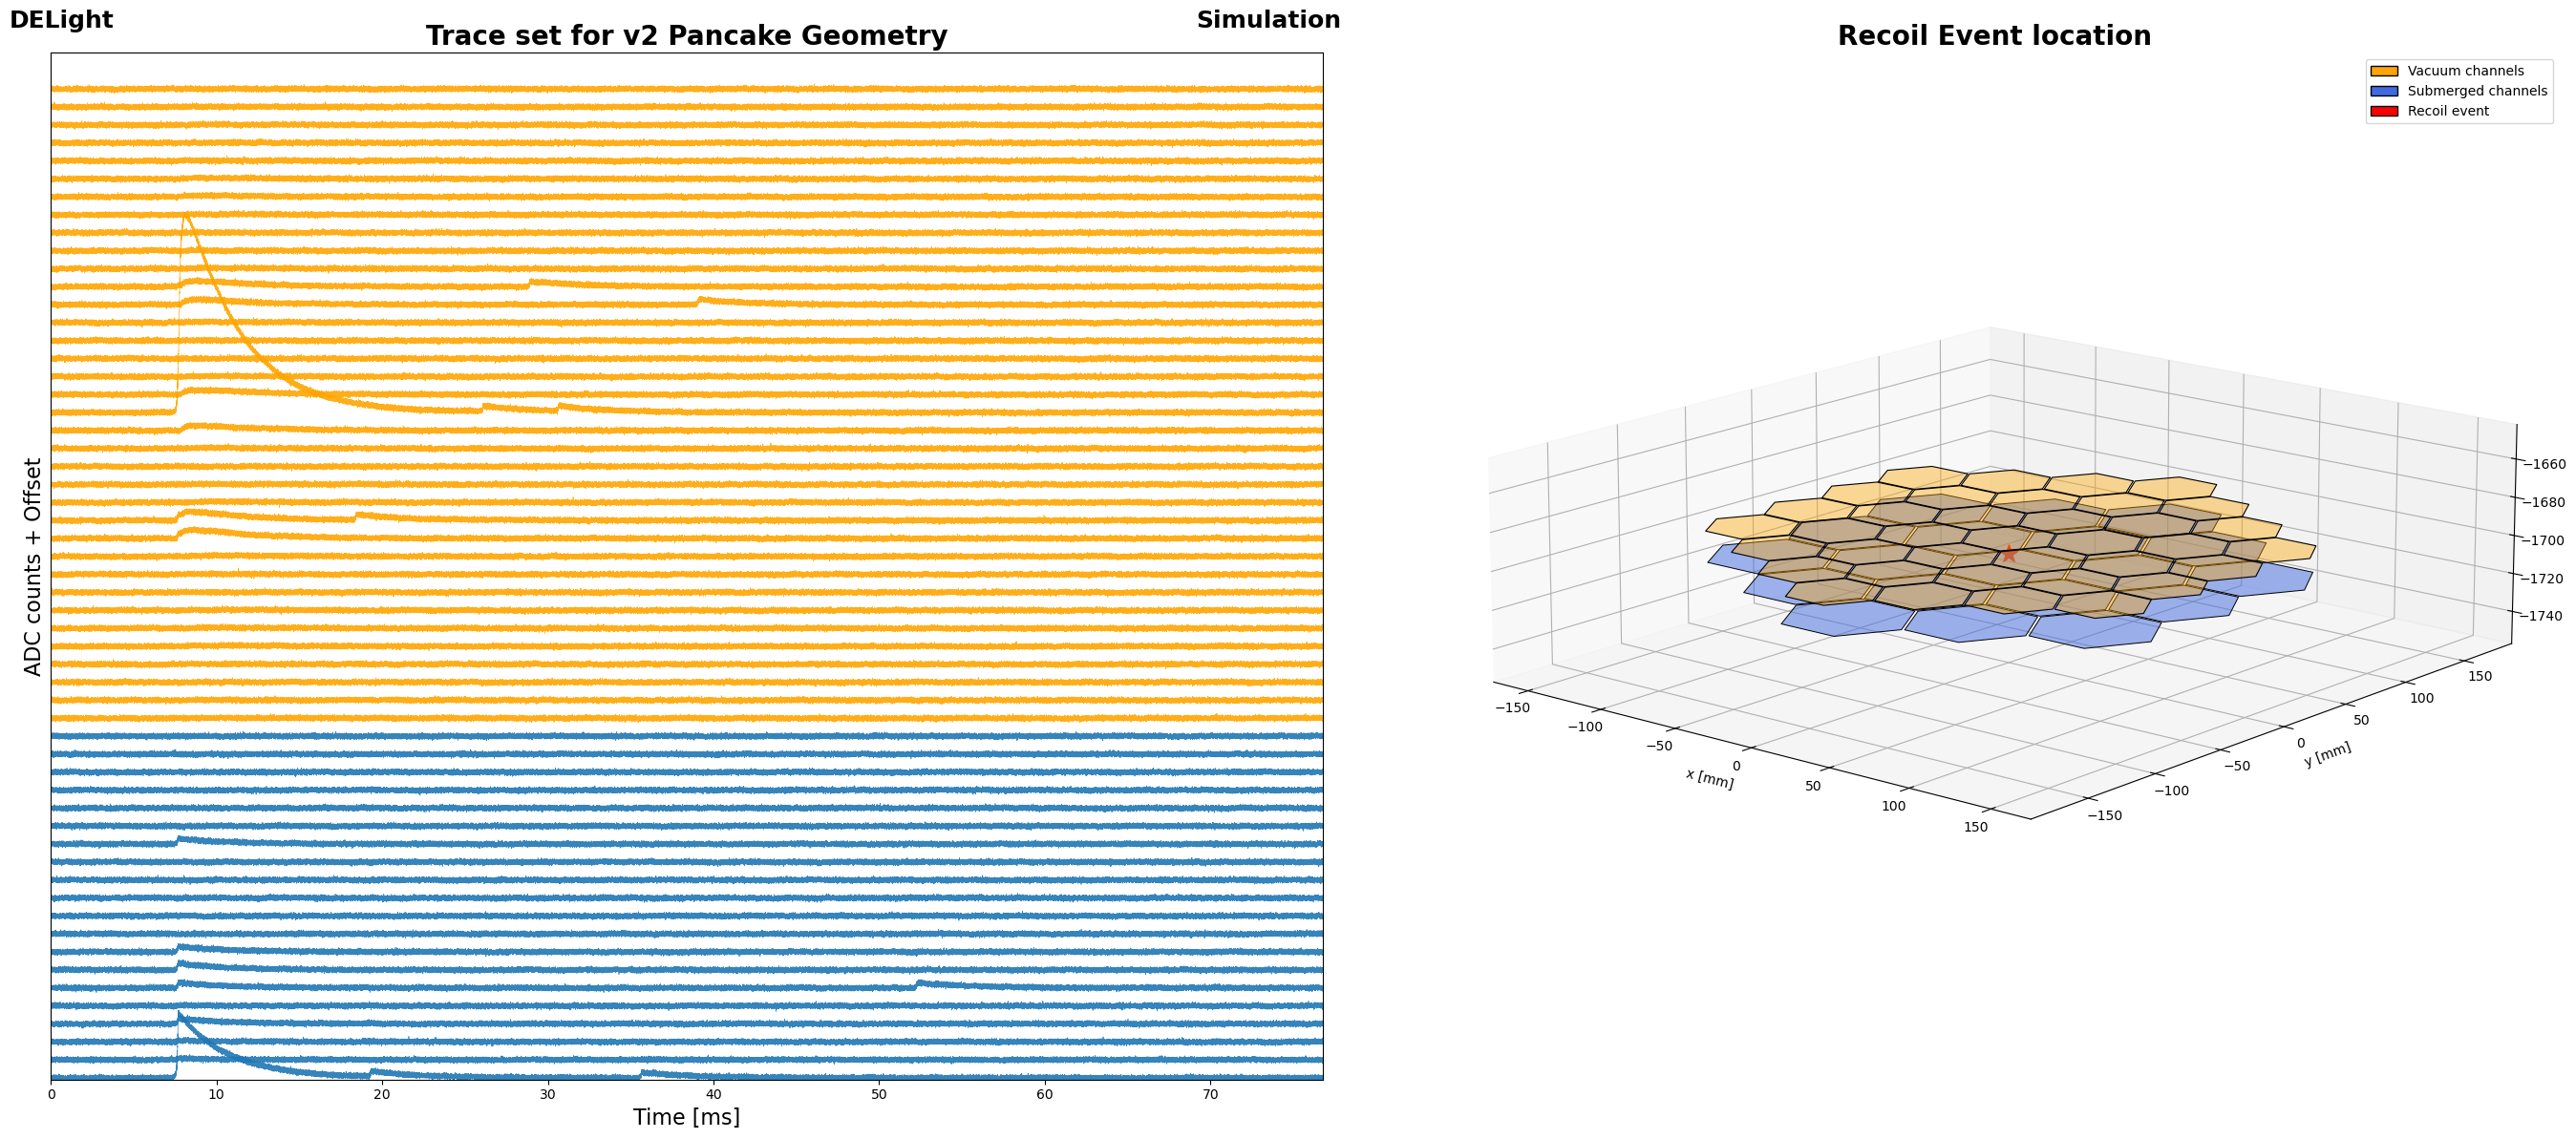

In [68]:
position =lts.LAMCAL_position
recoil_pos = (0, 0, -1700)  # Example recoil position
plot_traces_and_geometry(trace, position, recoil_pos)